In [101]:
import numpy as np
import matplotlib.pyplot as plt


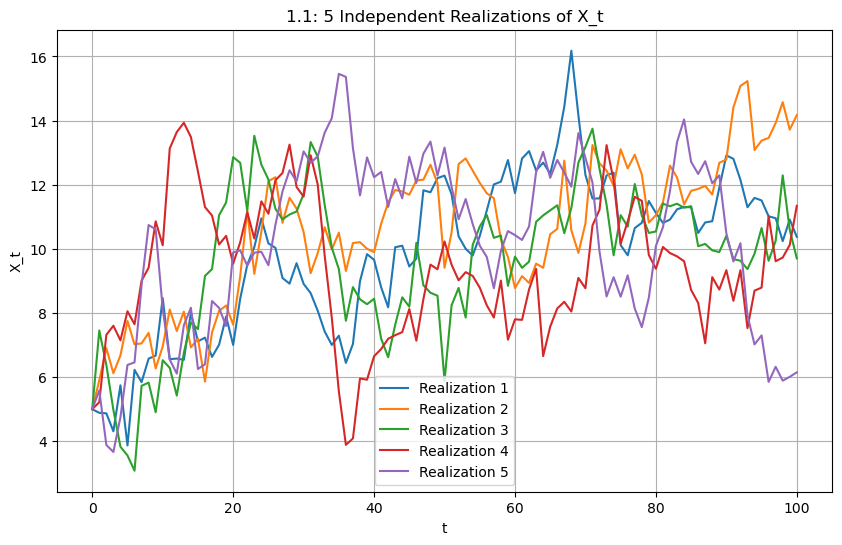

In [ ]:

# 1.1

a = 0.9
b = 1
sigma1 = 1
X0 = 5
n = 100
num_realizations = 5
seed = 1
# Set random seed
np.random.seed(seed)

# Store all trajectories
X_t = np.zeros((num_realizations, n + 1))
Y_t = np.zeros((num_realizations, n + 1))
X_t[:, 0] = X0


for i in range(num_realizations):
    for t in range(0, n+1):
        e_1_t = np.random.normal(0, sigma1)
        if t == 0:
            X_t[i,t] = X0
        else:
            X_t[i, t] = a * X_t[i, t - 1] + b + e_1_t
            
# Time axis
time = np.arange(n + 1)

# Plot all 5 trajectories
plt.figure(figsize=(10, 6))
for i in range(num_realizations):
    plt.plot(time, X_t[i], label=f"Realization {i+1}")
    

plt.title("1.1: 5 Independent Realizations of X_t")
plt.xlabel("t")
plt.ylabel("X_t")
plt.legend()
plt.grid(True)
plt.show()
plt.close()






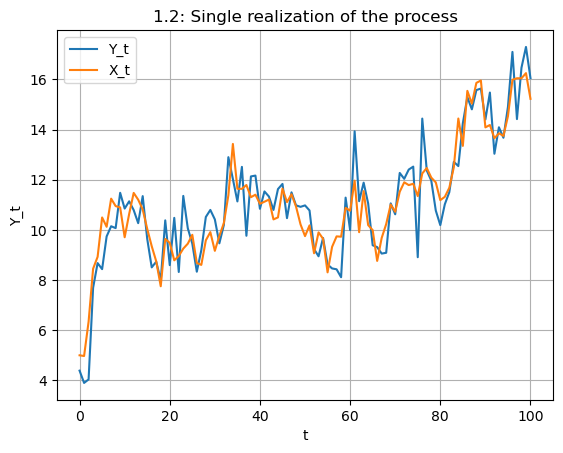

In [ ]:
# 1.2
np.random.seed(seed)

sigma2 = 1

num_realizations = 1

for i in range(num_realizations):
    for t in range(0, n+1):
        e_1_t = np.random.normal(0, sigma1)
        if t == 0:
            X_t[i,t] = X0
        else:
            X_t[i, t] = a * X_t[i, t - 1] + b + e_1_t
            
        e_2_t = np.random.normal(0,sigma2)
        Y_t[i,t] = X_t[i,t] +e_2_t
        
        
for i in range(num_realizations):
    plt.plot(time, Y_t[i],label = "Y_t")
    plt.plot(time,X_t[i],label = "X_t")

plt.title("1.2: Single realization of the process")
plt.xlabel("t")
plt.ylabel("Y_t")
plt.legend()
plt.grid(True)
plt.show()

Since the observation model $Y_t = X_t + \epsilon_2$, the noisy observations follow the true state $X_t$ closely, but fluctuate around it due to observation noise

## 1.3

The Kalman filter tracks the latent state well. The predicted state follows the general movement of the true state, while the observations are more scattered due to observation noise. The 95% confidence interval captures most of the true state values. The residuals fluctuate around zero, suggesting that the one-step-ahead predictions are approximately unbiased. Large residuals occur when the state noise produces sudden changes that cannot be predicted from previous observations

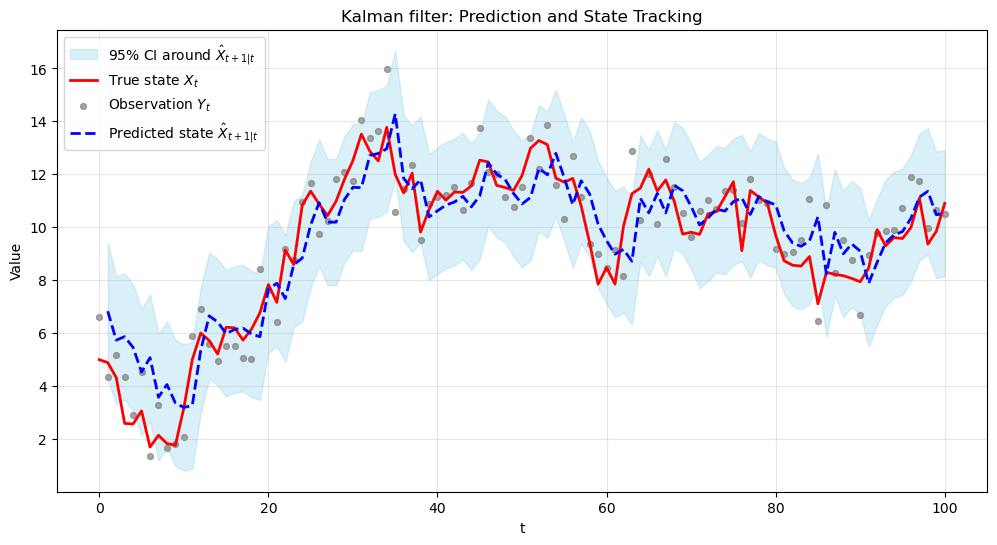

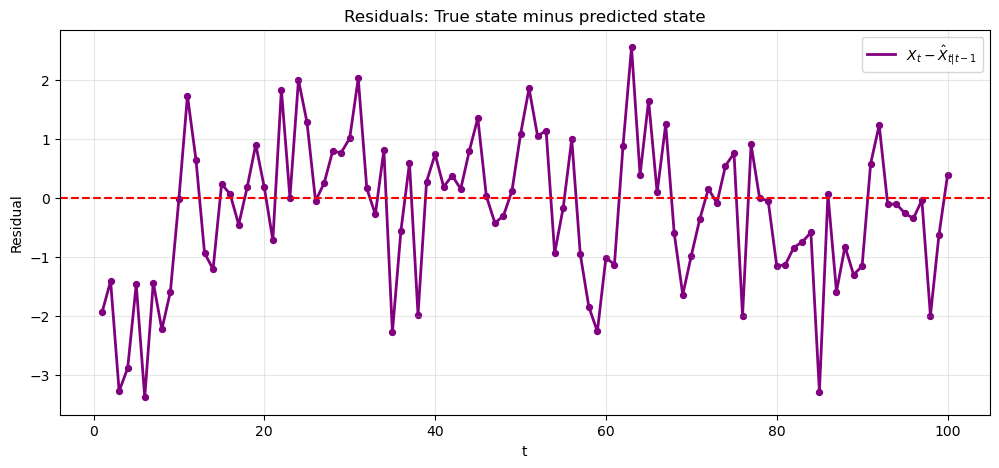

First x_pred_next values:
[6.82900984 5.73610738 5.86751204 5.45702806 4.53139769 5.07610174]

First P_pred_next values:
[1.73636364 1.51398671 1.48780259 1.48441147 1.48396705 1.48390872]

First innovations:
[ 1.62434536 -2.46893801 -0.54424915 -1.53043343 -2.5661557  -0.0040102 ]

First innovation variances:
[11.          2.73636364  2.51398671  2.48780259  2.48441147  2.48396705]

Residual mean:
-0.21989764905140496

Residual standard deviation:
1.2307522469686636


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1.2 DATA SIMULATION ---
np.random.seed(1)

a = 0.9
b = 1
sigma1 = 1
sigma2 = 1
X0 = 5
n = 100

time = np.arange(0, n + 1)

X_t = np.zeros(n + 1)
Y_t = np.zeros(n + 1)

X_t[0] = X0
Y_t[0] = X_t[0] + np.random.normal(0, sigma2)

for t in range(1, n + 1):
    X_t[t] = a * X_t[t - 1] + b + np.random.normal(0, sigma1)
    Y_t[t] = X_t[t] + np.random.normal(0, sigma2)


# --- 1.3 KALMAN FILTER ---
def myKalmanFilter(y, theta, R, x_prior=5, P_prior=10):
    """
    Kalman filter for:

        X_t = a X_{t-1} + b + e_t
        Y_t = X_t + v_t

    Returns both:
        x_pred       = prediction of X_t before observing Y_t
        x_pred_next  = prediction of X_{t+1} after observing Y_t
    """

    y = np.asarray(y, dtype=float)

    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]

    Q = sigma1**2
    N = len(y)

    x_pred = np.zeros(N)
    P_pred = np.zeros(N)

    x_filt = np.zeros(N)
    P_filt = np.zeros(N)

    innovation = np.zeros(N)
    innovation_var = np.zeros(N)

    x_pred_next = np.zeros(N)
    P_pred_next = np.zeros(N)

    for t in range(N):

        # Prediction of X_t before observing Y_t
        if t == 0:
            x_pred[t] = x_prior
            P_pred[t] = P_prior
        else:
            x_pred[t] = a * x_filt[t - 1] + b
            P_pred[t] = a**2 * P_filt[t - 1] + Q

        # Update with observation Y_t
        innovation[t] = y[t] - x_pred[t]
        innovation_var[t] = P_pred[t] + R

        K_t = P_pred[t] / innovation_var[t]

        x_filt[t] = x_pred[t] + K_t * innovation[t]
        P_filt[t] = (1 - K_t) * P_pred[t]

        # Prediction of X_{t+1|t}
        x_pred_next[t] = a * x_filt[t] + b
        P_pred_next[t] = a**2 * P_filt[t] + Q

    return {
        "x_pred": x_pred,
        "P_pred": P_pred,
        "x_filt": x_filt,
        "P_filt": P_filt,
        "innovation": innovation,
        "innovation_var": innovation_var,
        "x_pred_next": x_pred_next,
        "P_pred_next": P_pred_next
    }


# Run Kalman filter
theta = [a, b, sigma1]
R = sigma2**2

kf = myKalmanFilter(
    y=Y_t,
    theta=theta,
    R=R,
    x_prior=X0,
    P_prior=10
)


# --- 95% CI around X_{t+1|t} ---
ci_lower = kf["x_pred_next"] - 1.96 * np.sqrt(kf["P_pred_next"])
ci_upper = kf["x_pred_next"] + 1.96 * np.sqrt(kf["P_pred_next"])


# Align X_{t+1|t} with the time it predicts
# x_pred_next[0] predicts X_1, so plot it at time 1
pred_time = np.arange(1, n + 1)

pred_mean = kf["x_pred_next"][:n]
pred_lower = ci_lower[:n]
pred_upper = ci_upper[:n]


# --- PLOTTING ---
plt.figure(figsize=(12, 6))

plt.fill_between(
    pred_time,
    pred_lower,
    pred_upper,
    color="skyblue",
    alpha=0.3,
    label=r"95% CI around $\hat{X}_{t+1|t}$"
)

plt.plot(
    time,
    X_t,
    color="red",
    linewidth=2,
    label=r"True state $X_t$"
)

plt.scatter(
    time,
    Y_t,
    color="gray",
    s=18,
    alpha=0.7,
    label=r"Observation $Y_t$"
)

plt.plot(
    pred_time,
    pred_mean,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=r"Predicted state $\hat{X}_{t+1|t}$"
)

plt.title("Kalman filter: Prediction and State Tracking")
plt.xlabel("t")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# --- RESIDUALS: True state minus predicted state ---
# x_pred_next[0:n] predicts X_1, ..., X_n
true_next = X_t[1:n + 1]
pred_next = kf["x_pred_next"][:n]

residuals_pred = true_next - pred_next

plt.figure(figsize=(12, 5))

plt.plot(
    pred_time,
    residuals_pred,
    color="purple",
    linewidth=2,
    label=r"$X_t - \hat{X}_{t|t-1}$"
)

plt.scatter(
    pred_time,
    residuals_pred,
    color="purple",
    s=18
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residuals: True state minus predicted state")
plt.xlabel("t")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


print("First x_pred_next values:")
print(kf["x_pred_next"][:6])

print("\nFirst P_pred_next values:")
print(kf["P_pred_next"][:6])

print("\nFirst innovations:")
print(kf["innovation"][:6])

print("\nFirst innovation variances:")
print(kf["innovation_var"][:6])

print("\nResidual mean:")
print(np.mean(residuals_pred))

print("\nResidual standard deviation:")
print(np.std(residuals_pred, ddof=1))

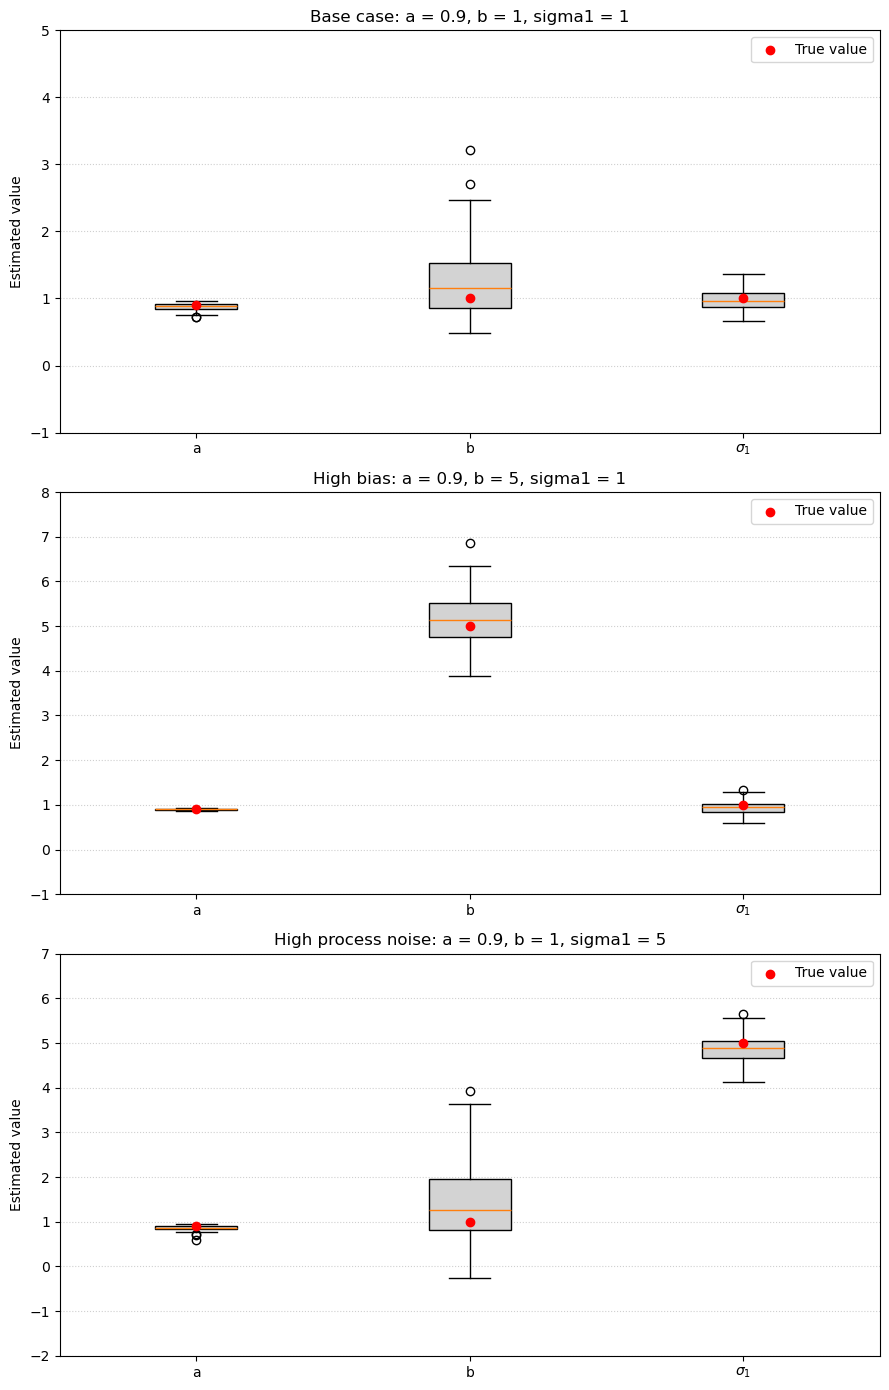


Base case: a = 0.9, b = 1, sigma1 = 1
True values:
a: 0.9000
b: 1.0000
sigma1: 1.0000

Mean estimates:
a: 0.8758
b: 1.2451
sigma1: 0.9711

Standard deviations:
a: 0.0512
b: 0.5200
sigma1: 0.1530

High bias: a = 0.9, b = 5, sigma1 = 1
True values:
a: 0.9000
b: 5.0000
sigma1: 1.0000

Mean estimates:
a: 0.8966
b: 5.1530
sigma1: 0.9412

Standard deviations:
a: 0.0125
b: 0.5676
sigma1: 0.1365

High process noise: a = 0.9, b = 1, sigma1 = 5
True values:
a: 0.9000
b: 1.0000
sigma1: 5.0000

Mean estimates:
a: 0.8613
b: 1.4652
sigma1: 4.8703

Standard deviations:
a: 0.0571
b: 0.8468
sigma1: 0.2920


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# ------------------------------------------------------------
# 1.3 Kalman filter
# ------------------------------------------------------------

def myKalmanFilter(y, theta, R, x_prior=0, P_prior=10):
    y = np.asarray(y, dtype=float)

    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]

    Q = sigma1**2
    N = len(y)

    x_pred = np.zeros(N)
    P_pred = np.zeros(N)
    x_filt = np.zeros(N)
    P_filt = np.zeros(N)
    innovation = np.zeros(N)
    innovation_var = np.zeros(N)

    x_pred_next = np.zeros(N)
    P_pred_next = np.zeros(N)

    for t in range(N):

        # Prediction of X_t before observing Y_t
        if t == 0:
            x_pred[t] = x_prior
            P_pred[t] = P_prior
        else:
            x_pred[t] = a * x_filt[t - 1] + b
            P_pred[t] = a**2 * P_filt[t - 1] + Q

        # Update with observation Y_t
        innovation[t] = y[t] - x_pred[t]
        innovation_var[t] = P_pred[t] + R

        K_t = P_pred[t] / innovation_var[t]

        x_filt[t] = x_pred[t] + K_t * innovation[t]
        P_filt[t] = (1 - K_t) * P_pred[t]

        # Prediction of X_{t+1|t}
        x_pred_next[t] = a * x_filt[t] + b
        P_pred_next[t] = a**2 * P_filt[t] + Q

    return {
        "x_pred": x_pred,
        "P_pred": P_pred,
        "x_filt": x_filt,
        "P_filt": P_filt,
        "innovation": innovation,
        "innovation_var": innovation_var,
        "x_pred_next": x_pred_next,
        "P_pred_next": P_pred_next
    }


# ------------------------------------------------------------
# 1.4 Negative log-likelihood function
# ------------------------------------------------------------

def myLogLikFun(theta, y, R, x_prior=0, P_prior=10):
    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]

    # sigma1 must be positive
    if sigma1 <= 0:
        return np.inf

    kf_result = myKalmanFilter(
        y=y,
        theta=[a, b, sigma1],
        R=R,
        x_prior=x_prior,
        P_prior=P_prior
    )

    err = kf_result["innovation"]
    S = kf_result["innovation_var"]

    # Variances must be positive
    if np.any(S <= 0):
        return np.inf

    # Log-likelihood from Gaussian innovations
    logL = np.sum(-0.5 * (np.log(2 * np.pi * S) + (err**2 / S)))

    # Return negative log-likelihood for minimization
    return -logL


# ------------------------------------------------------------
# Data simulation function
# ------------------------------------------------------------

def simulate_system(a, b, sigma1, sigma2, X0, n):
    X_t = np.zeros(n + 1)
    Y_t = np.zeros(n + 1)

    X_t[0] = X0
    Y_t[0] = X_t[0] + np.random.normal(0, sigma2)

    for t in range(1, n + 1):
        X_t[t] = a * X_t[t - 1] + b + np.random.normal(0, sigma1)
        Y_t[t] = X_t[t] + np.random.normal(0, sigma2)

    return X_t, Y_t


# ------------------------------------------------------------
# One estimation study
# ------------------------------------------------------------

def run_estimation_study(
    a_true,
    b_true,
    sigma1_true,
    sigma2=1,
    X0=5,
    n=100,
    n_sims=100
):
    estimates = []

    R = sigma2**2

    for _ in range(n_sims):

        X_t, Y_t = simulate_system(
            a=a_true,
            b=b_true,
            sigma1=sigma1_true,
            sigma2=sigma2,
            X0=X0,
            n=n
        )

        fit = minimize(
            fun=myLogLikFun,
            x0=np.array([0.5, 0.5, 1.0]),
            args=(Y_t, R, X0, 10),
            method="L-BFGS-B",
            bounds=[(None, None), (None, None), (0.001, None)]
        )

        if fit.success:
            estimates.append(fit.x)

    return np.array(estimates)


# ------------------------------------------------------------
# Run the three required cases
# ------------------------------------------------------------

np.random.seed(1)

cases = [
    {
        "params": [0.9, 1, 1],
        "label": "Base case: a = 0.9, b = 1, sigma1 = 1"
    },
    {
        "params": [0.9, 5, 1],
        "label": "High bias: a = 0.9, b = 5, sigma1 = 1"
    },
    {
        "params": [0.9, 1, 5],
        "label": "High process noise: a = 0.9, b = 1, sigma1 = 5"
    }
]

results = []

for case in cases:
    p = case["params"]

    estimates = run_estimation_study(
        a_true=p[0],
        b_true=p[1],
        sigma1_true=p[2],
        sigma2=1,
        X0=5,
        n=100,
        n_sims=100
    )

    results.append(estimates)


# ------------------------------------------------------------
# Boxplots of estimates with improved y-axes
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(9, 14))

for i, case in enumerate(cases):
    p = np.array(case["params"])
    estimates = results[i]

    ax = axes[i]

    y_min = np.floor(np.nanmin(np.concatenate([estimates.flatten(), p])))
    y_max = np.ceil(np.nanmax(np.concatenate([estimates.flatten(), p])))

    y_min -= 1
    y_max += 1

    y_ticks = np.arange(y_min, y_max + 1, 1)

    ax.boxplot(
        estimates,
        tick_labels=["a", "b", r"$\sigma_1$"],
        patch_artist=True,
        boxprops=dict(facecolor="lightgray")
    )

    ax.scatter(
        [1, 2, 3],
        p,
        color="red",
        label="True value",
        zorder=3
    )

    ax.set_title(case["label"])
    ax.set_ylabel("Estimated value")
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(y_ticks)
    ax.grid(axis="y", linestyle="dotted", alpha=0.6)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("MLE.png")
plt.show()


# ------------------------------------------------------------
# Numerical summaries
# ------------------------------------------------------------

param_names = ["a", "b", "sigma1"]

for i, case in enumerate(cases):
    estimates = results[i]
    p = np.array(case["params"])

    print("\n" + case["label"])

    print("True values:")
    for name, value in zip(param_names, p):
        print(f"{name}: {value:.4f}")

    print("\nMean estimates:")
    mean_estimates = np.mean(estimates, axis=0)
    for name, value in zip(param_names, mean_estimates):
        print(f"{name}: {value:.4f}")

    print("\nStandard deviations:")
    std_estimates = np.std(estimates, axis=0, ddof=1)
    for name, value in zip(param_names, std_estimates):
        print(f"{name}: {value:.4f}")

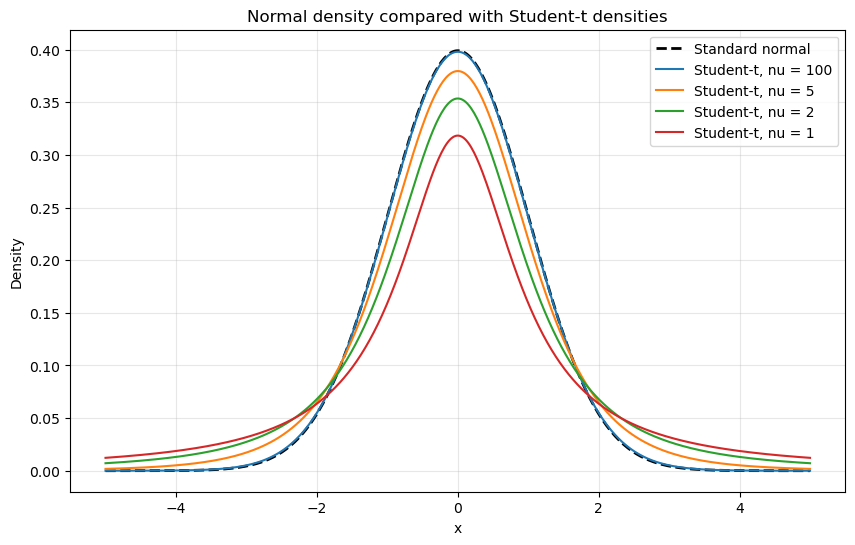

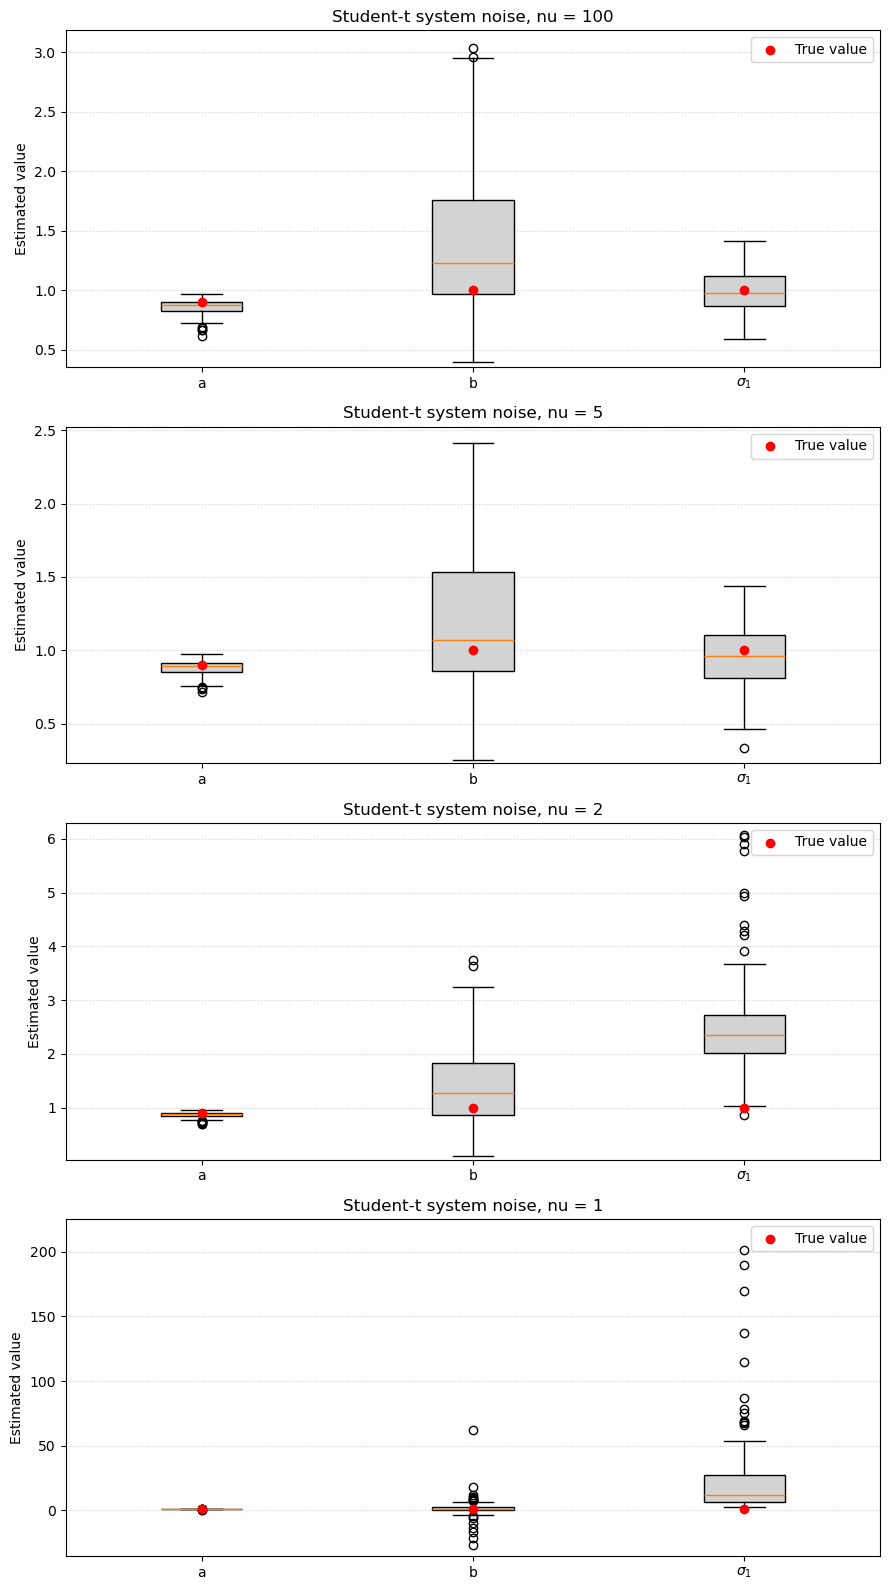

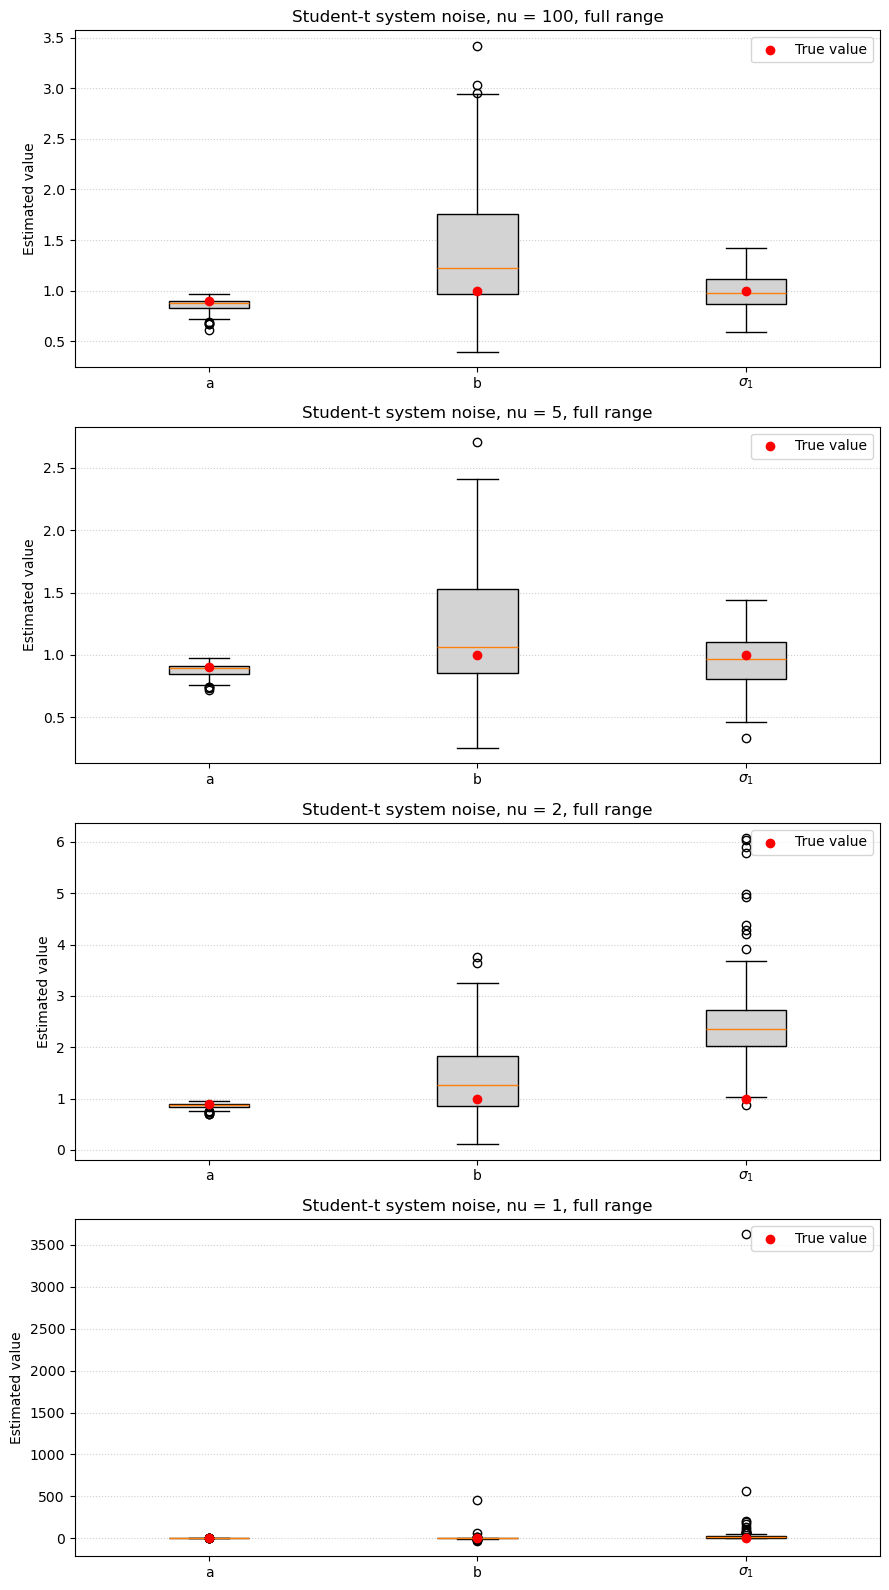


Student-t system noise, nu = 100
Number of successful estimates:
100

True values:
a: 0.9000
b: 1.0000
sigma1: 1.0000

Mean estimates:
a: 0.8562
b: 1.3984
sigma1: 0.9893

Median estimates:
a: 0.8755
b: 1.2257
sigma1: 0.9790

Standard deviations:
a: 0.0684
b: 0.6201
sigma1: 0.1604

1% and 99% quantiles:
a: [0.6656, 0.9562]
b: [0.5529, 3.0344]
sigma1: [0.6565, 1.2634]

Student-t system noise, nu = 5
Number of successful estimates:
100

True values:
a: 0.9000
b: 1.0000
sigma1: 1.0000

Mean estimates:
a: 0.8781
b: 1.2087
sigma1: 0.9556

Median estimates:
a: 0.8938
b: 1.0672
sigma1: 0.9639

Standard deviations:
a: 0.0547
b: 0.5300
sigma1: 0.2106

1% and 99% quantiles:
a: [0.7371, 0.9675]
b: [0.3307, 2.4177]
sigma1: [0.4605, 1.4009]

Student-t system noise, nu = 2
Number of successful estimates:
100

True values:
a: 0.9000
b: 1.0000
sigma1: 1.0000

Mean estimates:
a: 0.8650
b: 1.3899
sigma1: 2.5344

Median estimates:
a: 0.8723
b: 1.2651
sigma1: 2.3543

Standard deviations:
a: 0.0551
b: 0.71

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import t, norm


# ------------------------------------------------------------
# 1.3 Kalman filter
# ------------------------------------------------------------

def myKalmanFilter(y, theta, R, x_prior=0, P_prior=10):
    y = np.asarray(y, dtype=float)

    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]

    Q = sigma1**2
    N = len(y)

    x_pred = np.zeros(N)
    P_pred = np.zeros(N)

    x_filt = np.zeros(N)
    P_filt = np.zeros(N)

    innovation = np.zeros(N)
    innovation_var = np.zeros(N)

    x_pred_next = np.zeros(N)
    P_pred_next = np.zeros(N)

    for t_idx in range(N):

        # Prediction of X_t before observing Y_t
        if t_idx == 0:
            x_pred[t_idx] = x_prior
            P_pred[t_idx] = P_prior
        else:
            x_pred[t_idx] = a * x_filt[t_idx - 1] + b
            P_pred[t_idx] = a**2 * P_filt[t_idx - 1] + Q

        # Update with observation Y_t
        innovation[t_idx] = y[t_idx] - x_pred[t_idx]
        innovation_var[t_idx] = P_pred[t_idx] + R

        K_t = P_pred[t_idx] / innovation_var[t_idx]

        x_filt[t_idx] = x_pred[t_idx] + K_t * innovation[t_idx]
        P_filt[t_idx] = (1 - K_t) * P_pred[t_idx]

        # Prediction of X_{t+1|t}
        x_pred_next[t_idx] = a * x_filt[t_idx] + b
        P_pred_next[t_idx] = a**2 * P_filt[t_idx] + Q

    return {
        "x_pred": x_pred,
        "P_pred": P_pred,
        "x_filt": x_filt,
        "P_filt": P_filt,
        "innovation": innovation,
        "innovation_var": innovation_var,
        "x_pred_next": x_pred_next,
        "P_pred_next": P_pred_next
    }


# ------------------------------------------------------------
# Negative log-likelihood function
# ------------------------------------------------------------

def myLogLikFun(theta, y, R, x_prior=0, P_prior=10):
    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]

    if sigma1 <= 0:
        return np.inf

    kf_result = myKalmanFilter(
        y=y,
        theta=[a, b, sigma1],
        R=R,
        x_prior=x_prior,
        P_prior=P_prior
    )

    err = kf_result["innovation"]
    S = kf_result["innovation_var"]

    if np.any(S <= 0):
        return np.inf

    neg_logL = 0.5 * np.sum(
        np.log(2 * np.pi * S) + (err**2 / S)
    )

    return neg_logL


# ------------------------------------------------------------
# Plot normal and Student-t densities
# ------------------------------------------------------------

x_axis = np.linspace(-5, 5, 500)
nu_values = [100, 5, 2, 1]

plt.figure(figsize=(10, 6))

plt.plot(
    x_axis,
    norm.pdf(x_axis),
    "k--",
    label="Standard normal",
    linewidth=2
)

for nu in nu_values:
    plt.plot(
        x_axis,
        t.pdf(x_axis, df=nu),
        label=f"Student-t, nu = {nu}"
    )

plt.title("Normal density compared with Student-t densities")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ------------------------------------------------------------
# Simulate model with Student-t system noise
# ------------------------------------------------------------

def simulate_t_system(n, a, b, sigma1, sigma2, nu, X0=5):
    X_t = np.zeros(n + 1)
    Y_t = np.zeros(n + 1)

    X_t[0] = X0
    Y_t[0] = X_t[0] + np.random.normal(0, sigma2)

    for t_idx in range(1, n + 1):

        # Student-t process noise
        z = np.random.standard_t(df=nu)

        # For nu > 2, standardize so the variance is 1 before scaling by sigma1.
        # For nu <= 2, the variance is infinite or undefined, so no standardization is used.
        if nu > 2:
            z = z * np.sqrt((nu - 2) / nu)

        process_noise = sigma1 * z

        X_t[t_idx] = a * X_t[t_idx - 1] + b + process_noise
        Y_t[t_idx] = X_t[t_idx] + np.random.normal(0, sigma2)

    return X_t, Y_t


# ------------------------------------------------------------
# Estimation study for Student-t system noise
# ------------------------------------------------------------

def run_t_study(nu, n_sims=100, n_steps=100):
    estimates = []

    a_true = 0.9
    b_true = 1
    sigma1_true = 1
    sigma2 = 1
    X0 = 5
    R = sigma2**2

    for _ in range(n_sims):

        X_t, Y_t = simulate_t_system(
            n=n_steps,
            a=a_true,
            b=b_true,
            sigma1=sigma1_true,
            sigma2=sigma2,
            nu=nu,
            X0=X0
        )

        fit = minimize(
            fun=myLogLikFun,
            x0=np.array([0.5, 0.5, 1.0]),
            args=(Y_t, R, X0, 10),
            method="L-BFGS-B",
            bounds=[
                (None, None),
                (None, None),
                (0.001, None)
            ]
        )

        if fit.success:
            estimates.append(fit.x)

    return np.array(estimates)


# ------------------------------------------------------------
# Run studies
# ------------------------------------------------------------

np.random.seed(42)

t_results = []

for nu in nu_values:
    estimates = run_t_study(
        nu=nu,
        n_sims=100,
        n_steps=100
    )

    t_results.append(estimates)


# ------------------------------------------------------------
# Boxplots with robust y-axis limits
# ------------------------------------------------------------

fig, axes = plt.subplots(len(nu_values), 1, figsize=(9, 16))

true_values = np.array([0.9, 1.0, 1.0])

for i, nu in enumerate(nu_values):
    estimates = t_results[i]
    ax = axes[i]

    ax.boxplot(
        estimates,
        tick_labels=["a", "b", r"$\sigma_1$"],
        patch_artist=True,
        boxprops=dict(facecolor="lightgray")
    )

    ax.scatter(
        [1, 2, 3],
        true_values,
        color="red",
        label="True value",
        zorder=3
    )

    # Robust y-axis limits.
    # This prevents nu = 1 from destroying the plot because of extreme Cauchy outliers.
    flat_values = estimates.flatten()
    q_low = np.nanpercentile(flat_values, 1)
    q_high = np.nanpercentile(flat_values, 99)

    if q_low == q_high:
        q_low -= 1
        q_high += 1

    padding = 0.1 * (q_high - q_low)

    ax.set_ylim(q_low - padding, q_high + padding)

    ax.set_title(f"Student-t system noise, nu = {nu}")
    ax.set_ylabel("Estimated value")
    ax.grid(axis="y", linestyle="dotted", alpha=0.6)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Numerical summaries
# ------------------------------------------------------------

param_names = ["a", "b", "sigma1"]

for nu, estimates in zip(nu_values, t_results):

    print("\n" + f"Student-t system noise, nu = {nu}")

    print("Number of successful estimates:")
    print(len(estimates))

    print("\nTrue values:")
    for name, value in zip(param_names, true_values):
        print(f"{name}: {value:.4f}")

    print("\nMean estimates:")
    mean_estimates = np.mean(estimates, axis=0)
    for name, value in zip(param_names, mean_estimates):
        print(f"{name}: {value:.4f}")

    print("\nMedian estimates:")
    median_estimates = np.median(estimates, axis=0)
    for name, value in zip(param_names, median_estimates):
        print(f"{name}: {value:.4f}")

    print("\nStandard deviations:")
    std_estimates = np.std(estimates, axis=0, ddof=1)
    for name, value in zip(param_names, std_estimates):
        print(f"{name}: {value:.4f}")

    print("\n1% and 99% quantiles:")
    lower_quantiles = np.percentile(estimates, 1, axis=0)
    upper_quantiles = np.percentile(estimates, 99, axis=0)

    for name, low, high in zip(param_names, lower_quantiles, upper_quantiles):
        print(f"{name}: [{low:.4f}, {high:.4f}]")